# Исследование объявлений о продаже квартир

В вашем распоряжении данные сервиса Яндекс.Недвижимость — архив объявлений о продаже квартир в Санкт-Петербурге и соседних населённых пунктов за несколько лет. Нужно научиться определять рыночную стоимость объектов недвижимости. Ваша задача — установить параметры. Это позволит построить автоматизированную систему: она отследит аномалии и мошенническую деятельность. 

По каждой квартире на продажу доступны два вида данных. Первые вписаны пользователем, вторые — получены автоматически на основе картографических данных. Например, расстояние до центра, аэропорта, ближайшего парка и водоёма. 

### Откройте файл с данными и изучите общую информацию. 

In [1]:
#Импортируем сразу все необходимые библиотеки

import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv('/datasets/real_estate_data.csv', sep ="\t")

Вывод первых пяти строк данных для быстрого ознакомления.

In [2]:
data.head(5)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
0,20,13000000.0,108.0,2019-03-07T00:00:00,3,2.70,16.0,51.0,8,NaN,...,25.0,NaN,Санкт-Петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN
1,7,3350000.0,40.4,2018-12-04T00:00:00,1,NaN,11.0,18.6,1,NaN,...,11.0,2.0,посёлок Шушары,12817.0,18603.0,0.0,NaN,0.0,NaN,81.0
2,10,5196000.0,56.0,2015-08-20T00:00:00,2,NaN,5.0,34.3,4,NaN,...,8.3,0.0,Санкт-Петербург,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0
3,0,64900000.0,159.0,2015-07-24T00:00:00,3,NaN,14.0,NaN,9,NaN,...,NaN,0.0,Санкт-Петербург,28098.0,6800.0,2.0,84.0,3.0,234.0,424.0
4,2,10000000.0,100.0,2018-06-19T00:00:00,2,3.03,14.0,32.0,13,NaN,...,41.0,NaN,Санкт-Петербург,31856.0,8098.0,2.0,112.0,1.0,48.0,121.0


Вывод общей информации о данных, включая типы данных и количество непустых значений в каждом столбце.

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23699 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   total_images          23699 non-null  int64  
 1   last_price            23699 non-null  float64
 2   total_area            23699 non-null  float64
 3   first_day_exposition  23699 non-null  object 
 4   rooms                 23699 non-null  int64  
 5   ceiling_height        14504 non-null  float64
 6   floors_total          23613 non-null  float64
 7   living_area           21796 non-null  float64
 8   floor                 23699 non-null  int64  
 9   is_apartment          2775 non-null   object 
 10  studio                23699 non-null  bool   
 11  open_plan             23699 non-null  bool   
 12  kitchen_area          21421 non-null  float64
 13  balcony               12180 non-null  float64
 14  locality_name         23650 non-null  object 
 15  airports_nearest   

Переименуем сразу столбец 'cityCenters_nearest' в 'city_centers_nearest' с помощью метода **rename** для упрощение работы с этим столбцом в дальнейшем.

In [4]:
data.rename(columns={'cityCenters_nearest': 'city_centers_nearest'}, inplace=True)

Построим гистограмму для всех числовых столбцов таблицы на одном графике.

array([[<AxesSubplot:title={'center':'total_images'}>,
        <AxesSubplot:title={'center':'last_price'}>,
        <AxesSubplot:title={'center':'total_area'}>,
        <AxesSubplot:title={'center':'rooms'}>],
       [<AxesSubplot:title={'center':'ceiling_height'}>,
        <AxesSubplot:title={'center':'floors_total'}>,
        <AxesSubplot:title={'center':'living_area'}>,
        <AxesSubplot:title={'center':'floor'}>],
       [<AxesSubplot:title={'center':'kitchen_area'}>,
        <AxesSubplot:title={'center':'balcony'}>,
        <AxesSubplot:title={'center':'airports_nearest'}>,
        <AxesSubplot:title={'center':'city_centers_nearest'}>],
       [<AxesSubplot:title={'center':'parks_around3000'}>,
        <AxesSubplot:title={'center':'parks_nearest'}>,
        <AxesSubplot:title={'center':'ponds_around3000'}>,
        <AxesSubplot:title={'center':'ponds_nearest'}>],
       [<AxesSubplot:title={'center':'days_exposition'}>, <AxesSubplot:>,
        <AxesSubplot:>, <AxesSubplot:>]], 

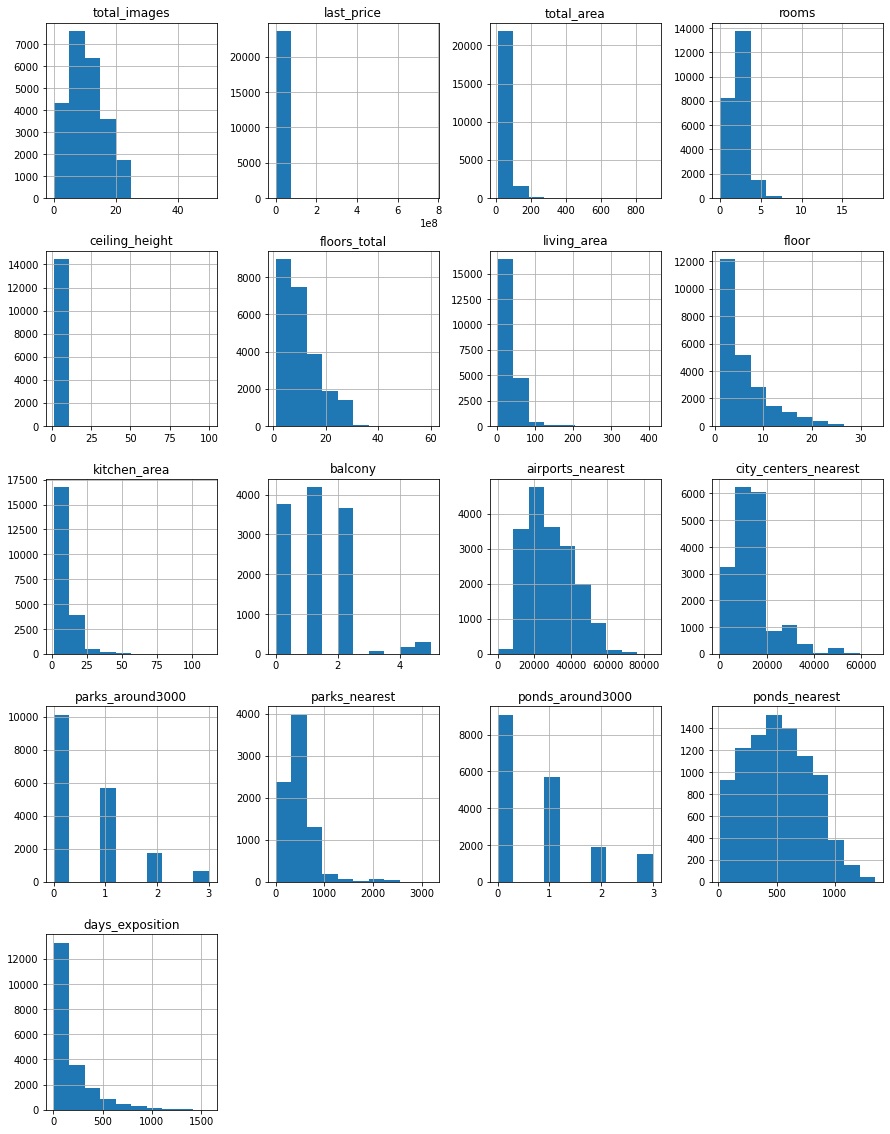

In [5]:
data.hist(figsize=(15, 20))

In [6]:
# Код ревьюера
rz = data.shape[0]

### Предобработка данных

Преступим к преобработке данных. Выводим через **isna().sum()** количества пропущенных значений для каждого столбца.


In [7]:
data.isna().sum()

total_images                0
last_price                  0
total_area                  0
first_day_exposition        0
rooms                       0
ceiling_height           9195
floors_total               86
living_area              1903
floor                       0
is_apartment            20924
studio                      0
open_plan                   0
kitchen_area             2278
balcony                 11519
locality_name              49
airports_nearest         5542
city_centers_nearest     5519
parks_around3000         5518
parks_nearest           15620
ponds_around3000         5518
ponds_nearest           14589
days_exposition          3181
dtype: int64

Заполним пропущенные значения в столбцах 'ceiling_height', 'floors_total', 'living_area', 'kitchen_area' и др.

In [8]:
data['ceiling_height'].fillna(data['ceiling_height'].median(), inplace=True)

In [9]:
#data['floors_total'].fillna(data['floors_total'].mode()[0], inplace=True)

# Удаление строк с пропущенными значениями в столбце floors_total
data.dropna(subset=['floors_total'], inplace=True)

In [10]:
#data['living_area'].fillna(data['living_area'].median(), inplace=True)
#data['kitchen_area'].fillna(data['kitchen_area'].median(), inplace=True)

In [11]:
# Cоотношение медианной жилой площади к медианной общей площади
median_ratio_living_total = data['living_area'].median() / data['total_area'].median()

# Заполняем пропуски в столбце living_area на основе найденного соотношения
data['living_area'].fillna(data['total_area'] * median_ratio_living_total, inplace=True)

# Повторяем тот же процесс со столбцом kitchen_area
median_ratio_kitchen_total = data['kitchen_area'].median() / data['total_area'].median()

data['kitchen_area'].fillna(data['total_area'] * median_ratio_kitchen_total, inplace=True)

In [12]:
data['is_apartment'].fillna(False, inplace=True) 
data['balcony'].fillna(0, inplace=True)  

#data['parks_around3000'].fillna(0, inplace=True)  # Assuming 0 as a default value
#data['ponds_around3000'].fillna(0, inplace=True)  # Assuming 0 as a default value


Выводим первые пять строк данных после заполнения пропущенных значений.

In [13]:
data.head()

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,kitchen_area,balcony,locality_name,airports_nearest,city_centers_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
0,20,13000000.0,108.0,2019-03-07T00:00:00,3,2.70,16.0,51.000000,8,False,...,25.000,0.0,Санкт-Петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN
1,7,3350000.0,40.4,2018-12-04T00:00:00,1,2.65,11.0,18.600000,1,False,...,11.000,2.0,посёлок Шушары,12817.0,18603.0,0.0,NaN,0.0,NaN,81.0
2,10,5196000.0,56.0,2015-08-20T00:00:00,2,2.65,5.0,34.300000,4,False,...,8.300,0.0,Санкт-Петербург,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0
3,0,64900000.0,159.0,2015-07-24T00:00:00,3,2.65,14.0,91.730769,9,False,...,27.825,0.0,Санкт-Петербург,28098.0,6800.0,2.0,84.0,3.0,234.0,424.0
4,2,10000000.0,100.0,2018-06-19T00:00:00,2,3.03,14.0,32.000000,13,False,...,41.000,0.0,Санкт-Петербург,31856.0,8098.0,2.0,112.0,1.0,48.0,121.0


Начнем преобразовывать формат данных в столбцах. Для начала возьмем столбец 'first_day_exposition' и заменим формат на datetime.


In [14]:
data['first_day_exposition'] = pd.to_datetime(data['first_day_exposition'], format='%Y-%m-%dT%H:%M:%S')

Приведем типы данных столбцов к целочисленному типу данных с использованием astype.

In [15]:
data['floors_total'] = data['floors_total'].astype('Int64') 

In [16]:
data['balcony'] = data['balcony'].astype('Int64') 

In [17]:
data['parks_around3000'] = data['parks_around3000'].astype('Int64') 

In [18]:
data['ponds_around3000'] = data['ponds_around3000'].astype('Int64') 

Заполним пропущенные значения в столбце 'days_exposition' нулями, округлим и приведем к целочисленному типу данных.

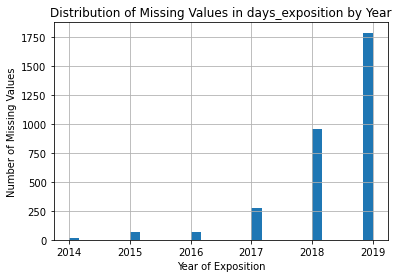

In [20]:
# Создаем новый столбец с годом выставления квартиры на продажу
data['year_exposition'] = data['first_day_exposition'].dt.year

# Гистограмма распределения пропусков относительно года
data[data['days_exposition'].isna()]['year_exposition'].hist(bins=30)
plt.title('Distribution of Missing Values in days_exposition by Year')
plt.xlabel('Year of Exposition')
plt.ylabel('Number of Missing Values')
plt.show()

Гистограмма распределения пропусков в столбце days_exposition относительно года позволяет нам увидеть, что количество пропусков значительно возрастает в 2018 и 2019 годах. Возможно, что квартира еще не была продана на момент выгрузки данных. Если объявление еще активно или не было снято с публикации, система может не иметь информации о количестве дней, прошедших с момента размещения до момента снятия.

Выводим обновленную информацию о данных после проведенной предобработки.

In [21]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 23613 entries, 0 to 23698
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   total_images          23613 non-null  int64         
 1   last_price            23613 non-null  float64       
 2   total_area            23613 non-null  float64       
 3   first_day_exposition  23613 non-null  datetime64[ns]
 4   rooms                 23613 non-null  int64         
 5   ceiling_height        23613 non-null  float64       
 6   floors_total          23613 non-null  Int64         
 7   living_area           23613 non-null  float64       
 8   floor                 23613 non-null  int64         
 9   is_apartment          23613 non-null  bool          
 10  studio                23613 non-null  bool          
 11  open_plan             23613 non-null  bool          
 12  kitchen_area          23613 non-null  float64       
 13  balcony         

Устраним неявные дубликаты в названиях населённых пунктов. Для начала выведем количество уникальных значенрие в столбце 'locality_name'.

In [22]:
# Устранение неявных дубликатов в названиях населённых пунктов
data['locality_name'].nunique()

364

Вывод уникальных значений в столбце 'locality_name' для оценки разнообразия данных.

In [23]:
data['locality_name'].unique() 


array(['Санкт-Петербург', 'посёлок Шушары', 'городской посёлок Янино-1',
       'посёлок Парголово', 'посёлок Мурино', 'Ломоносов', 'Сертолово',
       'Петергоф', 'Пушкин', 'деревня Кудрово', 'Коммунар', 'Колпино',
       'поселок городского типа Красный Бор', 'Гатчина', 'поселок Мурино',
       'деревня Фёдоровское', 'Выборг', 'Кронштадт', 'Кировск',
       'деревня Новое Девяткино', 'посёлок Металлострой',
       'посёлок городского типа Лебяжье',
       'посёлок городского типа Сиверский', 'поселок Молодцово',
       'поселок городского типа Кузьмоловский',
       'садовое товарищество Новая Ропша', 'Павловск',
       'деревня Пикколово', 'Всеволожск', 'Волхов', 'Кингисепп',
       'Приозерск', 'Сестрорецк', 'деревня Куттузи', 'посёлок Аннино',
       'поселок городского типа Ефимовский', 'посёлок Плодовое',
       'деревня Заклинье', 'поселок Торковичи', 'поселок Первомайское',
       'Красное Село', 'посёлок Понтонный', 'Сясьстрой', 'деревня Старая',
       'деревня Лесколово', '

Замена значений в столбце 'locality_name', чтобы унифицировать данные (например, замена "посёлок" на "поселок" и замена буквы "ё" на "е").

In [24]:
data['locality_name'] = data['locality_name'].str.replace('посёлок', 'поселок') 
data['locality_name'] = data['locality_name'].str.replace(r'(?<=[а-я])ё(?=[а-я])', 'е', regex=True)
data['locality_name'].unique()

array(['Санкт-Петербург', 'поселок Шушары', 'городской поселок Янино-1',
       'поселок Парголово', 'поселок Мурино', 'Ломоносов', 'Сертолово',
       'Петергоф', 'Пушкин', 'деревня Кудрово', 'Коммунар', 'Колпино',
       'поселок городского типа Красный Бор', 'Гатчина',
       'деревня Фёдоровское', 'Выборг', 'Кронштадт', 'Кировск',
       'деревня Новое Девяткино', 'поселок Металлострой',
       'поселок городского типа Лебяжье',
       'поселок городского типа Сиверский', 'поселок Молодцово',
       'поселок городского типа Кузьмоловский',
       'садовое товарищество Новая Ропша', 'Павловск',
       'деревня Пикколово', 'Всеволожск', 'Волхов', 'Кингисепп',
       'Приозерск', 'Сестрорецк', 'деревня Куттузи', 'поселок Аннино',
       'поселок городского типа Ефимовский', 'поселок Плодовое',
       'деревня Заклинье', 'поселок Торковичи', 'поселок Первомайское',
       'Красное Село', 'поселок Понтонный', 'Сясьстрой', 'деревня Старая',
       'деревня Лесколово', 'поселок Новый Свет

Проверка количества уникальных значений в столбце 'locality_name' после выполнения замен.

In [25]:
data['locality_name'].nunique()

330

Замена значений в столбце 'locality_name' для дополнительной унификации. Видим, что можно заменить **садовое товарищество, поселок городского типа, городской поселок, коттеджный поселок** на **поселок**.

In [26]:
data['locality_name'] = data['locality_name'].replace({'садовое товарищество|поселок городского типа|городской поселок|коттеджный поселок': 'поселок'}, regex=True)

Повторный вывод уникальных значений в столбце 'locality_name' после дополнительной замены.

In [27]:
data['locality_name'].nunique()

319

In [28]:
data['locality_name'].unique()

array(['Санкт-Петербург', 'поселок Шушары', 'поселок Янино-1',
       'поселок Парголово', 'поселок Мурино', 'Ломоносов', 'Сертолово',
       'Петергоф', 'Пушкин', 'деревня Кудрово', 'Коммунар', 'Колпино',
       'поселок Красный Бор', 'Гатчина', 'деревня Фёдоровское', 'Выборг',
       'Кронштадт', 'Кировск', 'деревня Новое Девяткино',
       'поселок Металлострой', 'поселок Лебяжье', 'поселок Сиверский',
       'поселок Молодцово', 'поселок Кузьмоловский',
       'поселок Новая Ропша', 'Павловск', 'деревня Пикколово',
       'Всеволожск', 'Волхов', 'Кингисепп', 'Приозерск', 'Сестрорецк',
       'деревня Куттузи', 'поселок Аннино', 'поселок Ефимовский',
       'поселок Плодовое', 'деревня Заклинье', 'поселок Торковичи',
       'поселок Первомайское', 'Красное Село', 'поселок Понтонный',
       'Сясьстрой', 'деревня Старая', 'деревня Лесколово',
       'поселок Новый Свет', 'Сланцы', 'село Путилово', 'Ивангород',
       'Мурино', 'Шлиссельбург', 'Никольское', 'Зеленогорск',
       'Сосн

Вывод статистического описания числовых данных для поиска аномальных значений. 

In [29]:
data.describe()

,total_images,last_price,total_area,rooms,ceiling_height,floors_total,living_area,floor,kitchen_area,balcony,airports_nearest,city_centers_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,year_exposition
count,23613.000000,2.361300e+04,23613.000000,23613.000000,23613.000000,23613.000000,23613.000000,23613.000000,23613.000000,23613.000000,18081.000000,18104.000000,18105.000000,8045.000000,18105.000000,9061.000000,20441.000000,23613.000000
mean,9.874518,6.540555e+06,60.340678,2.071147,2.724581,10.673824,34.631561,5.877313,10.502668,0.593063,28788.008185,14185.084015,0.611433,490.554630,0.770119,518.209469,180.884839,2017.368102
std,5.681541,1.090172e+07,35.648988,1.078380,0.990085,6.597173,22.394364,4.873539,6.040009,0.960307,12626.209956,8614.132292,0.802168,341.336698,0.939075,277.887489,219.685543,1.039383
min,0.000000,1.219000e+04,12.000000,0.000000,1.000000,1.000000,2.000000,1.000000,1.300000,0.000000,0.000000,181.000000,0.000000,1.000000,0.000000,13.000000,1.000000,2014.000000
25%,6.000000,3.400000e+06,40.000000,1.000000,2.600000,5.000000,19.000000,2.000000,7.000000,0.000000,18575.000000,9233.750000,0.000000,288.000000,0.000000,294.000000,45.000000,2017.000000
50%,9.000000,4.650000e+06,52.000000,2.000000,2.650000,9.000000,30.000000,4.000000,9.000000,0.000000,26726.000000,13093.000000,0.000000,455.000000,1.000000,503.000000,95.000000,2017.000000
75%,14.000000,6.799000e+06,69.800000,3.000000,2.700000,16.000000,42.173077,8.000000,12.000000,1.000000,37242.000000,16287.000000,1.000000,612.000000,1.000000,730.000000,232.000000,2018.000000
max,50.000000,7.630000e+08,900.000000,19.000000,100.000000,60.000000,409.700000,33.000000,112.000000,5.000000,84869.000000,65968.000000,3.000000,3190.000000,3.000000,1344.000000,1580.000000,2019.000000


Видим, что есть аномальные значения в столбце ceiling_height, где максимальное значение достигает 100 м. Скорей всего, при заполнении этого параметра продавец использовал сантиметры, поэтому унифицируем данные. 

In [30]:
data.loc[data['ceiling_height'] >= 10, 'ceiling_height'] = data['ceiling_height'] / 10

Повторный выводим статистическое описание после коррекции.

In [31]:
data.describe()

,total_images,last_price,total_area,rooms,ceiling_height,floors_total,living_area,floor,kitchen_area,balcony,airports_nearest,city_centers_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,year_exposition
count,23613.000000,2.361300e+04,23613.000000,23613.000000,23613.000000,23613.000000,23613.000000,23613.000000,23613.000000,23613.000000,18081.000000,18104.000000,18105.000000,8045.000000,18105.000000,9061.000000,20441.000000,23613.000000
mean,9.874518,6.540555e+06,60.340678,2.071147,2.697923,10.673824,34.631561,5.877313,10.502668,0.593063,28788.008185,14185.084015,0.611433,490.554630,0.770119,518.209469,180.884839,2017.368102
std,5.681541,1.090172e+07,35.648988,1.078380,0.238047,6.597173,22.394364,4.873539,6.040009,0.960307,12626.209956,8614.132292,0.802168,341.336698,0.939075,277.887489,219.685543,1.039383
min,0.000000,1.219000e+04,12.000000,0.000000,1.000000,1.000000,2.000000,1.000000,1.300000,0.000000,0.000000,181.000000,0.000000,1.000000,0.000000,13.000000,1.000000,2014.000000
25%,6.000000,3.400000e+06,40.000000,1.000000,2.600000,5.000000,19.000000,2.000000,7.000000,0.000000,18575.000000,9233.750000,0.000000,288.000000,0.000000,294.000000,45.000000,2017.000000
50%,9.000000,4.650000e+06,52.000000,2.000000,2.650000,9.000000,30.000000,4.000000,9.000000,0.000000,26726.000000,13093.000000,0.000000,455.000000,1.000000,503.000000,95.000000,2017.000000
75%,14.000000,6.799000e+06,69.800000,3.000000,2.700000,16.000000,42.173077,8.000000,12.000000,1.000000,37242.000000,16287.000000,1.000000,612.000000,1.000000,730.000000,232.000000,2018.000000
max,50.000000,7.630000e+08,900.000000,19.000000,10.000000,60.000000,409.700000,33.000000,112.000000,5.000000,84869.000000,65968.000000,3.000000,3190.000000,3.000000,1344.000000,1580.000000,2019.000000


In [32]:
#Вывод первых строк данных после проведенных изменений.
data.head()

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,balcony,locality_name,airports_nearest,city_centers_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,year_exposition
0,20,13000000.0,108.0,2019-03-07,3,2.70,16,51.000000,8,False,...,0,Санкт-Петербург,18863.0,16028.0,1,482.0,2,755.0,NaN,2019
1,7,3350000.0,40.4,2018-12-04,1,2.65,11,18.600000,1,False,...,2,поселок Шушары,12817.0,18603.0,0,NaN,0,NaN,81.0,2018
2,10,5196000.0,56.0,2015-08-20,2,2.65,5,34.300000,4,False,...,0,Санкт-Петербург,21741.0,13933.0,1,90.0,2,574.0,558.0,2015
3,0,64900000.0,159.0,2015-07-24,3,2.65,14,91.730769,9,False,...,0,Санкт-Петербург,28098.0,6800.0,2,84.0,3,234.0,424.0,2015
4,2,10000000.0,100.0,2018-06-19,2,3.03,14,32.000000,13,False,...,0,Санкт-Петербург,31856.0,8098.0,2,112.0,1,48.0,121.0,2018


### Посчитайте и добавьте в таблицу новые столбцы

Расчет и добавление нового столбца 'price_per_square_meter' в таблицу, представляющего цену за квадратный метр.

In [33]:
# Добавим столбец с ценой одного квадратного метра;
data['price_per_square_meter'] = data['last_price'] / data['total_area']
data['price_per_square_meter'] = data['price_per_square_meter'].round(2)
print(data['price_per_square_meter'])

0        120370.37
1         82920.79
2         92785.71
3        408176.10
4        100000.00
           ...    
23694     72490.85
23695     52542.37
23696     44091.71
23697    149511.40
23698     41795.67
Name: price_per_square_meter, Length: 23613, dtype: float64


Добавление столбцов с днем недели, месяцем и годом размещения объявления на основе столбца 'first_day_exposition'.

In [34]:
data['day_exposition'] = data['first_day_exposition'].dt.dayofweek
data['month_exposition'] = data['first_day_exposition'].dt.month
data['year_exposition'] = data['first_day_exposition'].dt.year


#Выведем первые 10 строчек для проверки
data.head(10)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,city_centers_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,year_exposition,price_per_square_meter,day_exposition,month_exposition
0,20,13000000.0,108.00,2019-03-07,3,2.70,16,51.000000,8,False,...,16028.0,1,482.0,2,755.0,NaN,2019,120370.37,3,3
1,7,3350000.0,40.40,2018-12-04,1,2.65,11,18.600000,1,False,...,18603.0,0,NaN,0,NaN,81.0,2018,82920.79,1,12
2,10,5196000.0,56.00,2015-08-20,2,2.65,5,34.300000,4,False,...,13933.0,1,90.0,2,574.0,558.0,2015,92785.71,3,8
3,0,64900000.0,159.00,2015-07-24,3,2.65,14,91.730769,9,False,...,6800.0,2,84.0,3,234.0,424.0,2015,408176.10,4,7
4,2,10000000.0,100.00,2018-06-19,2,3.03,14,32.000000,13,False,...,8098.0,2,112.0,1,48.0,121.0,2018,100000.00,1,6
5,10,2890000.0,30.40,2018-09-10,1,2.65,12,14.400000,5,False,...,NaN,<NA>,NaN,<NA>,NaN,55.0,2018,95065.79,0,9
6,6,3700000.0,37.30,2017-11-02,1,2.65,26,10.600000,6,False,...,19143.0,0,NaN,0,NaN,155.0,2017,99195.71,3,11
7,5,7915000.0,71.60,2019-04-18,2,2.65,24,41.307692,22,False,...,11634.0,0,NaN,0,NaN,NaN,2019,110544.69,3,4
8,20,2900000.0,33.16,2018-05-23,1,2.65,27,15.430000,26,False,...,NaN,<NA>,NaN,<NA>,NaN,189.0,2018,87454.76,2,5
9,18,5400000.0,61.00,2017-02-26,3,2.50,9,43.600000,7,False,...,15008.0,0,NaN,0,NaN,289.0,2017,88524.59,6,2


Определение категории этажа для каждой записи в таблице на основе столбцов 'floor' и 'floors_total' с использованием функции floors_cat и добавление нового столбца 'floors_category'.


In [35]:
def floors_cat(row):
    floor = row['floor']
    floors_total = row['floors_total']
    if floor == 1:
        return 'первый'
    if floor == floors_total:
        return 'последний'
    if pd.isna(floor):
        return 'Неизвестно'
    return 'другой'
data['floors_category'] = data.apply(floors_cat, axis = 1)

#Вывод количества значений в новом столбце 'floors_category' для оценки распределения.
data['floors_category'].value_counts(dropna=False)

другой       17363
последний     3336
первый        2914
Name: floors_category, dtype: int64

Создание нового столбца **'city_centers_nearest_km'**, представляющего расстояние до центра города в километрах.

In [36]:
# Расстояние до центра города в километрах (переведите из м в км и округлите до целых значений).
data['city_centers_nearest_km'] = round(data['city_centers_nearest'] / 1000)
data.head(10)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,year_exposition,price_per_square_meter,day_exposition,month_exposition,floors_category,city_centers_nearest_km
0,20,13000000.0,108.00,2019-03-07,3,2.70,16,51.000000,8,False,...,482.0,2,755.0,NaN,2019,120370.37,3,3,другой,16.0
1,7,3350000.0,40.40,2018-12-04,1,2.65,11,18.600000,1,False,...,NaN,0,NaN,81.0,2018,82920.79,1,12,первый,19.0
2,10,5196000.0,56.00,2015-08-20,2,2.65,5,34.300000,4,False,...,90.0,2,574.0,558.0,2015,92785.71,3,8,другой,14.0
3,0,64900000.0,159.00,2015-07-24,3,2.65,14,91.730769,9,False,...,84.0,3,234.0,424.0,2015,408176.10,4,7,другой,7.0
4,2,10000000.0,100.00,2018-06-19,2,3.03,14,32.000000,13,False,...,112.0,1,48.0,121.0,2018,100000.00,1,6,другой,8.0
5,10,2890000.0,30.40,2018-09-10,1,2.65,12,14.400000,5,False,...,NaN,<NA>,NaN,55.0,2018,95065.79,0,9,другой,NaN
6,6,3700000.0,37.30,2017-11-02,1,2.65,26,10.600000,6,False,...,NaN,0,NaN,155.0,2017,99195.71,3,11,другой,19.0
7,5,7915000.0,71.60,2019-04-18,2,2.65,24,41.307692,22,False,...,NaN,0,NaN,NaN,2019,110544.69,3,4,другой,12.0
8,20,2900000.0,33.16,2018-05-23,1,2.65,27,15.430000,26,False,...,NaN,<NA>,NaN,189.0,2018,87454.76,2,5,другой,NaN
9,18,5400000.0,61.00,2017-02-26,3,2.50,9,43.600000,7,False,...,NaN,0,NaN,289.0,2017,88524.59,6,2,другой,15.0


### Проведите исследовательский анализ данных

Построение гистограмм для различных параметров и времени продажи, а также вывод среднего и медианного времени продажи.

<AxesSubplot:>

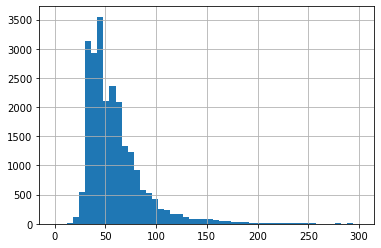

In [37]:
#Общая площадь 
data['total_area'].hist(bins=50, range=(0, 300))

<AxesSubplot:>

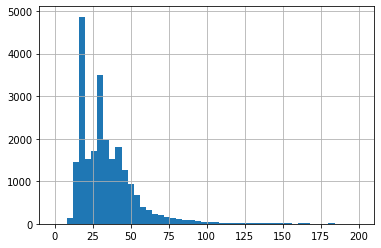

In [38]:
#Жилая площадь
data['living_area'].hist(bins=50, range=(0, 200))

<AxesSubplot:>

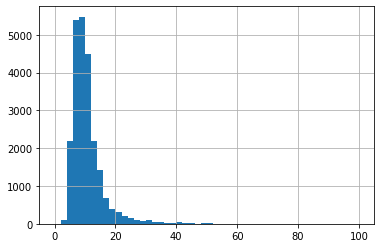

In [39]:
data['kitchen_area'].hist(bins=50, range=(0, 100))

<AxesSubplot:>

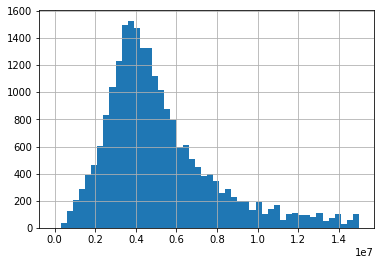

In [40]:
#Цена объекта
data['last_price'].hist(bins=50, range=(0, 15000000))

<AxesSubplot:>

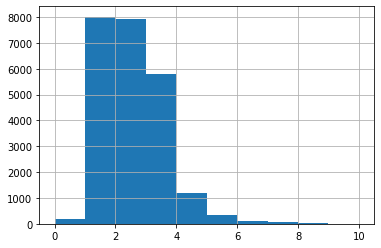

In [41]:
#Количество комнат
data['rooms'].hist(bins=10, range=(0, 10))

<AxesSubplot:>

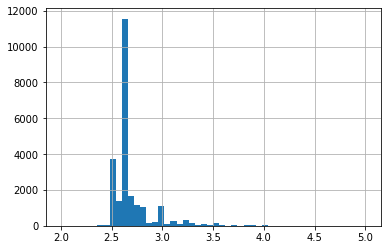

In [42]:
#Высота потолков
data['ceiling_height'].hist(bins=50, range=(2,5))

<AxesSubplot:>

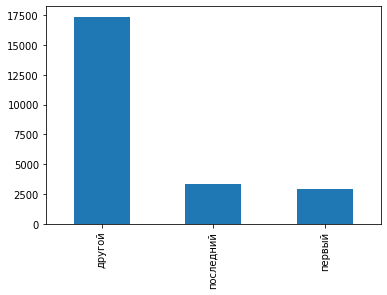

In [43]:
# Тип этажа квартиры
data['floors_category'].value_counts().plot(kind='bar')

<AxesSubplot:>

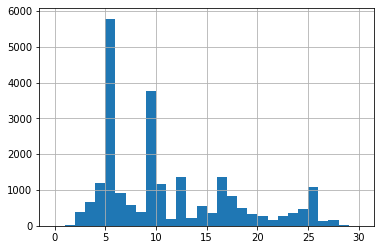

In [44]:
#Общее количество этажей в доме:
data['floors_total'].hist(bins=30, range=(0, 30))

<AxesSubplot:>

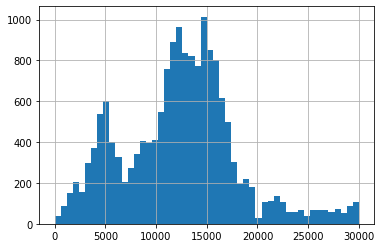

In [45]:
#Расстояние до центра города в километрах:
data['city_centers_nearest'].hist(bins=50, range=(0, 30000))

<AxesSubplot:>

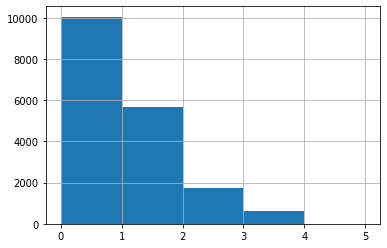

In [46]:
#Расстояние до ближайшего парка
data['parks_around3000'].hist(bins=5, range=(0, 5))

In [47]:
data.shape[0]/rz*100

23613

Как быстро продавались квартиры (столбец days_exposition)

Среднее время продажи: 180.88483929357665 дня
Медианное время продажи: 95.0 дня


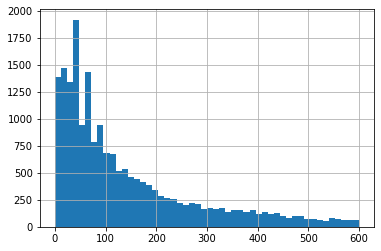

In [48]:
# Гистограмма времени продажи
data['days_exposition'].hist(bins=50, range=(0, 600))
mean_days = data['days_exposition'].mean()
median_days = data['days_exposition'].median()
print("Среднее время продажи:", mean_days, 'дня')
print("Медианное время продажи:", median_days, 'дня')

Видим, что достаточно много значений приходит на 0. Это скорее всего, указывает на то, что объявление было активно менее одного дня или было снято в тот же день, что и размещено. Однако кажется, что это не совсем реалистично в разговоре о продаже недвижимости, поэтому попробуем построить гистограмму, исклювич нулевые значения. 

Среднее время продажи (без значений 0): 180.88483929357665
Медианное время продажи (без значений 0): 95.0


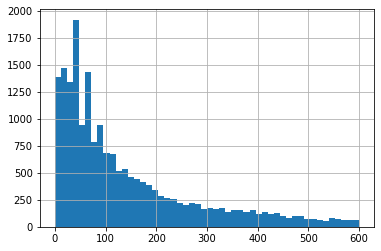

In [49]:
data[data['days_exposition'] > 0]['days_exposition'].hist(bins=50, range=(0, 600))

# Пересчет среднего и медианы без значений 0
print("Среднее время продажи (без значений 0):", data[data['days_exposition'] > 0]['days_exposition'].mean())
print("Медианное время продажи (без значений 0):", data[data['days_exposition'] > 0]['days_exposition'].median())

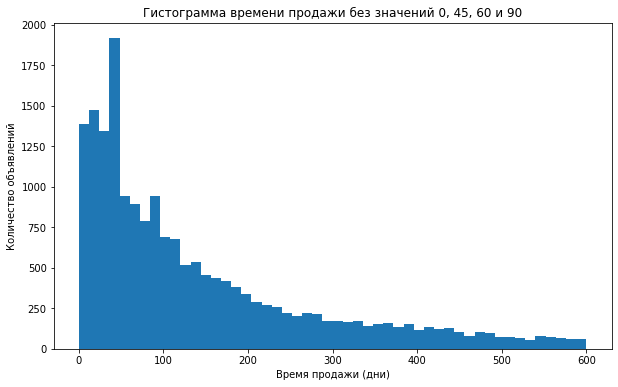

In [50]:
plt.figure(figsize=(10, 6))
plt.hist(data[(data['days_exposition'] > 0) & 
              (data['days_exposition'] != 45) & 
              (data['days_exposition'] != 60) & 
              (data['days_exposition'] != 90)]['days_exposition'], bins=50, range=(0, 600))
plt.title('Гистограмма времени продажи без значений 0, 45, 60 и 90')
plt.xlabel('Время продажи (дни)')
plt.ylabel('Количество объявлений')
plt.show()

Видим, что убрать нулевые значения, мы получили более точную информацию о сроках продажи объектов недвижимости. Так, достаточно много объектов продается менее чем 3 месяца. 

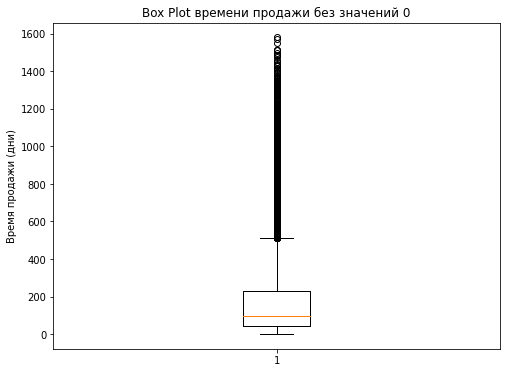

Среднее время продажи (без значений 0): 180.88483929357665
Медианное время продажи (без значений 0): 95.0


In [51]:
# Создаем диаграмму размаха для времени продажи без значений 0
plt.figure(figsize=(8, 6))
plt.boxplot(data[data['days_exposition'] > 0]['days_exposition'])
plt.title('Box Plot времени продажи без значений 0')
plt.ylabel('Время продажи (дни)')
plt.show()

# Выводим среднее и медиану без значений 0
mean_days = data[data['days_exposition'] > 0]['days_exposition'].mean()
median_days = data[data['days_exposition'] > 0]['days_exposition'].median()
print("Среднее время продажи (без значений 0):", mean_days)
print("Медианное время продажи (без значений 0):", median_days)

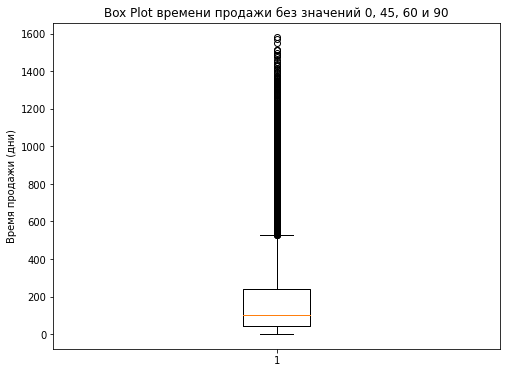

Среднее время продажи (без значений 0, 45, 60 и 90): 184.152489574436
Медианное время продажи (без значений 0, 45, 60 и 90): 100.0


In [52]:
plt.figure(figsize=(8, 6))
plt.boxplot(data[(data['days_exposition'] > 0) & 
                 (data['days_exposition'] != 45) & 
                 (data['days_exposition'] != 60) & 
                 (data['days_exposition'] != 90)]['days_exposition'])
plt.title('Box Plot времени продажи без значений 0, 45, 60 и 90')
plt.ylabel('Время продажи (дни)')
plt.show()

# Выводим среднее и медиану без значений 0, 45, 60 и 90
filtered_days = data[(data['days_exposition'] > 0) & 
                     (data['days_exposition'] != 45) & 
                     (data['days_exposition'] != 60) & 
                     (data['days_exposition'] != 90)]['days_exposition']

mean_days = filtered_days.mean()
median_days = filtered_days.median()

print("Среднее время продажи (без значений 0, 45, 60 и 90):", mean_days)
print("Медианное время продажи (без значений 0, 45, 60 и 90):", median_days)

**Построение графиков зависимости цены от различных параметров.**

<AxesSubplot:xlabel='total_area', ylabel='last_price'>

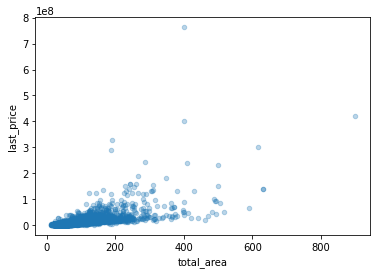

In [53]:
#Общая площадь
data.plot(x='total_area', y='last_price', kind='scatter', alpha=0.3)

<AxesSubplot:xlabel='living_area', ylabel='last_price'>

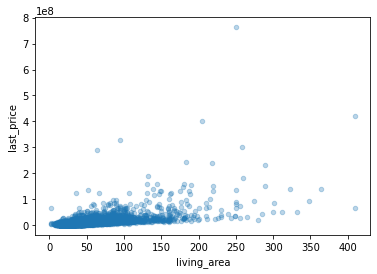

In [54]:
#Жилая площадь:
data.plot(x='living_area', y='last_price', kind='scatter', alpha=0.3)

<AxesSubplot:xlabel='kitchen_area', ylabel='last_price'>

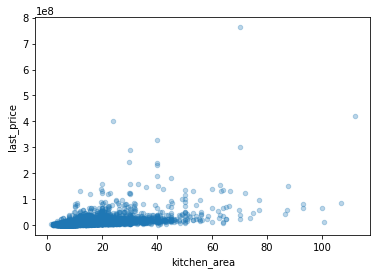

In [55]:
#Площадь кухни:
data.plot(x='kitchen_area', y='last_price', kind='scatter', alpha=0.3)

<AxesSubplot:xlabel='rooms', ylabel='last_price'>

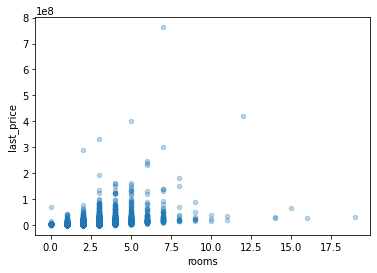

In [56]:
#Количество комнат:
data.plot(x='rooms', y='last_price', kind='scatter', alpha=0.3)

<AxesSubplot:xlabel='floors_category'>

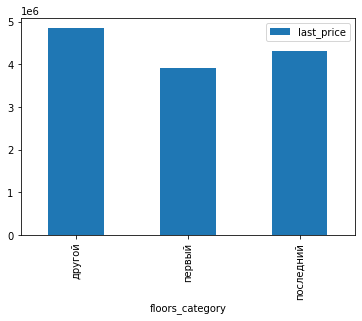

In [57]:
#Этаж квартиры:
data.pivot_table(index='floors_category', values='last_price', aggfunc='median').plot(kind='bar')

Исходя из графика можно сделать вывод, что объекты на первом этаже, как правило, стоят ниже чем объекты на последним или любых других этажах.

<AxesSubplot:xlabel='day_exposition'>

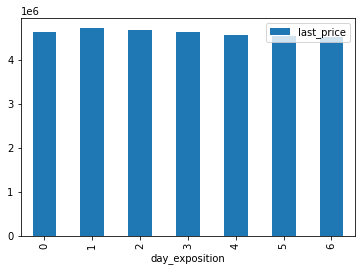

In [58]:
#День недели размещения
data.pivot_table(index='day_exposition', values='last_price', aggfunc='median').plot(kind='bar')

День недели размещения объявления никак не влияет на стоимость.

<AxesSubplot:xlabel='month_exposition'>

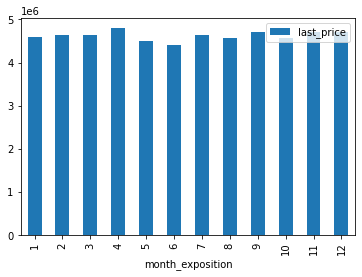

In [59]:
#Месяц размещения:
data.pivot_table(index='month_exposition', values='last_price', aggfunc='median').plot(kind='bar')

По графику заметно, что в июле объекты несколько теряют в стоимости, что может быть связано с периодом отпусков. В целом же по графику не заметна корреляция между месяцем продажи и ценой объектов.

<AxesSubplot:xlabel='year_exposition'>

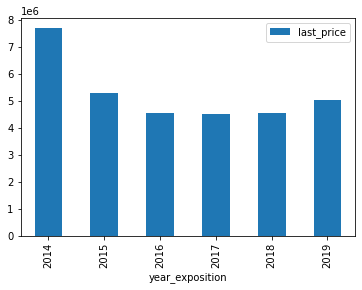

In [60]:
#Год размещения:
data.pivot_table(index='year_exposition', values='last_price', aggfunc='median').plot(kind='bar')

Объекты, которые были размещены в 2014 стоят значительно дороже, чем те, что были размещены позднее. Этому может быть несколько причин: в этот год было достаточно много объектов с большой площадью, что так сильно могло заафектить данные, либо же цены на недвижимость в этот год действительно были такими высокими. Построим график, где рассчитаем среднюю стоимость за квадратный метр для каждого года. 

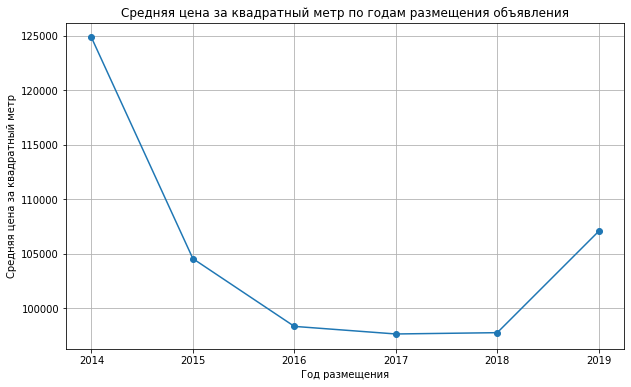

In [61]:
# Вычисление средней цены за квадратный метр для каждого года
mean_price_per_meter_by_year = data.groupby('year_exposition')['price_per_square_meter'].mean()

# Построение графика
plt.figure(figsize=(10, 6))
plt.plot(mean_price_per_meter_by_year, marker='o', linestyle='-')
plt.title('Средняя цена за квадратный метр по годам размещения объявления')
plt.xlabel('Год размещения')
plt.ylabel('Средняя цена за квадратный метр')
plt.grid(True)
plt.show()

График средней цены за квадратный метр несколько похож на график стоимость объектов, что подтверждает гипотезу о том, как менялись цены на недвижимость. В 2014 году квадратный метр жилья стоил 125,000 рублей, но с 2015 по 2018 год цены снижались и держались ниже 100,000 рублей. В 2019 году цены немного поднялись до 107,000 рублей. Эти изменения могут отражать, как менялся рынок недвижимости и что влияло на цены.

**Посчитаем среднюю цену одного квадратного метра в 10 населённых пунктах с наибольшим числом объявлений — построим сводную таблицу с количеством объявлений и средней ценой квадратного метра для этих населенных пунктов. Выделим населённые пункты с самой высокой и низкой стоимостью квадратного метр**

In [62]:
# Выбираем 10 населенных пунктов с наибольшим числом объявлений
top_localities = data['locality_name'].value_counts().head(10).index

# Строим сводную таблицу
pivot_table_localities = data[data['locality_name'].isin(top_localities)].pivot_table(index='locality_name', values=['price_per_square_meter'], aggfunc={'price_per_square_meter': ['count', 'mean']})

# Даем подходящие имена столбцам
pivot_table_localities.columns = ['count', 'mean_price_per_square_meter']

# Выводим результат
print(pivot_table_localities.sort_values(by='mean_price_per_square_meter', ascending=False))

                   count  mean_price_per_square_meter
locality_name                                        
Санкт-Петербург    15651                114868.877339
Пушкин               369                103125.819377
деревня Кудрово      299                 92473.547559
поселок Парголово    327                 90175.913089
поселок Мурино       552                 85629.568641
поселок Шушары       439                 78551.344647
Колпино              338                 75424.579112
Гатчина              307                 68746.146515
Всеволожск           398                 68654.473970
Выборг               237                 58141.909325


Цены на жилье варьируются в разных населенных пунктах, причем Санкт-Петербург и Пушкин имеют более высокие цены по сравнению с другими местами. Дял наглядности вывода построим столбчатую диаграмму.

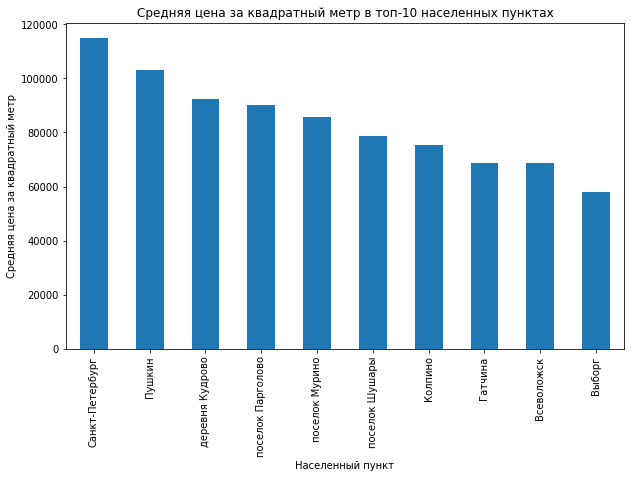

In [63]:
import matplotlib.pyplot as plt
pivot_table_localities_sorted = pivot_table_localities.sort_values(by='mean_price_per_square_meter', ascending=False)

pivot_table_localities_sorted['mean_price_per_square_meter'].plot(kind='bar', figsize=(10, 6))
plt.title('Средняя цена за квадратный метр в топ-10 населенных пунктах')
plt.xlabel('Населенный пункт')
plt.ylabel('Средняя цена за квадратный метр')
plt.show()

**Вывод**: Санкт-Петербург имеет самую высокую среднюю стоимость квадратного метра среди всех населенных пунктов в списке, что вполне ожидаемо для крупного города.

Пушкин занимает второе место по стоимости квадратного метра, что может быть связано с престижностью и историческим значением этого населенного пункта.

Деревня Кудрово и поселок Парголово занимают третье и четвертое места соответственно. Они обладают средней стоимостью квадратного метра, превышающей среднюю стоимость в регионе.

Поселок Мурино, поселок Шушары, Колпино, Гатчина, Всеволожск и Выборг следуют далее в списке. Стоимость квадратного метра в этих населенных пунктах варьируется, но в целом она ниже, чем в Санкт-Петербурге и Пушкине.



**Расчет и построение графика зависимости средней цены от расстояния до центра Петербурга для квартир в Санкт-Петербурге.**

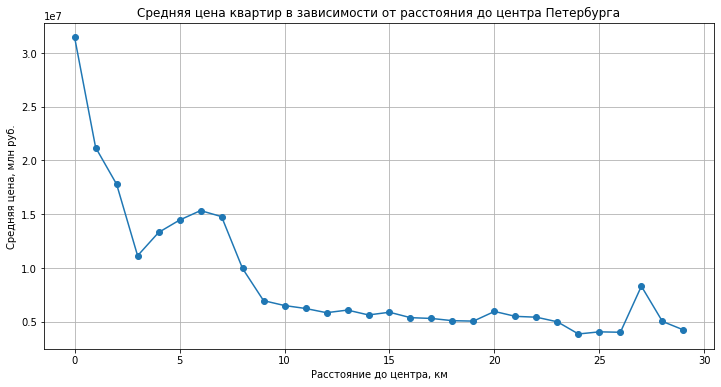

In [64]:
# Выберем квартиры в Санкт-Петербурге
spb_data = data[data['locality_name'] == 'Санкт-Петербург']

# Посчитаем среднюю цену для каждого километра от центра
mean_price_per_km = spb_data.groupby('city_centers_nearest_km')['last_price'].mean()

# Построим график изменения средней цены для каждого километра от центра Петербурга
mean_price_per_km.plot(x='city_centers_nearest_km', y='last_price', style='o-', grid=True, figsize=(12, 6))
plt.title('Средняя цена квартир в зависимости от расстояния до центра Петербурга')
plt.xlabel('Расстояние до центра, км')
plt.ylabel('Средняя цена, млн руб.')
plt.show()

На графике видно, что в самом центре города, где расстояние до центра равно 0, цены на жилье самые высокие. С постепенным удалением от центра цены снижаются. Это может указывать на привлекательность центральных районов и снижение стоимости жилья по мере удаления от центра.

### Общий вывод

Проведенный исследовательский анализ данных по недвижимости в Ленинградской области выявил ряд ключевых трендов. Удаление нулевых значений в столбце сроков продажи позволило получить более точную информацию. Большинство объектов продается в течение трех месяцев.

Анализ этажности показал, что квартиры на первом этаже, как правило, стоят ниже, чем на последних или других этажах. День недели размещения объявления не оказывает существенного влияния на стоимость. Заметен небольшой спад цен в июле, возможно, связанный с периодом отпусков.

График зависимости цены от года размещения показал, что объекты, размещенные в 2014 году, стоят значительно дороже. Возможные причины: большая площадь объектов в этот год или реально высокие цены в указанный период.

В 2014 году средняя цена за квадратный метр недвижимости была выше (125,000 рублей), чем в последующие годы. В период с 2015 по 2018 годы цены снижались, удерживаясь ниже 100,000 рублей, и лишь в 2019 году произошло некоторое восстановление, с подъемом цен до 107,000 рублей.

Цены на жилье сильно варьируются в разных населенных пунктах. Санкт-Петербург и Пушкин имеют более высокие цены, а стоимость жилья в других населенных пунктах варьируется в зависимости от удаленности от центра.

График зависимости средней цены за квадратный метр от года подтверждает изменения в рыночных трендах. Объекты в Санкт-Петербурге оказались самыми дорогими, что соответствует ожиданиям для крупного города.

В общем, проведенный анализ предоставляет полезные инсайты для понимания рынка недвижимости в регионе.